# Análise de sensibilidade e cenários de um projeto de investimento

**Google Colab:** abra este notebook e escolha **Ambiente de execução → Executar tudo**. Altere as premissas na primeira célula de código e execute novamente.

Reprodução do exercício da planilha *Sensibilidade e Cenarios-Exercicios.xlsx*: investimento de R$ 750.000, vida útil de 5 anos, vendas de 500 unidades/ano, preço de R$ 2.500, custo variável de R$ 1.500/unidade e custo fixo de R$ 200.000/ano. Alíquota: 34%. TMA: 17% a.a.

**Convenções:** custos e investimento são digitados como valores positivos. As saídas de caixa recebem sinal negativo nos fluxos. Depreciação linear até zero, receitas e custos anuais constantes, recebimentos no fim de cada ano, sem capital de giro. O residual é recebido no último ano, líquido de imposto sobre ganho em relação ao valor contábil zero. Como na planilha, o imposto é calculado como LAJIR × alíquota, inclusive com benefício fiscal imediato quando há prejuízo. É possível desligar esse benefício na célula de premissas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.optimize import brentq
from IPython.display import display

# EDITE AQUI: valores monetários em reais, taxas em decimais.
BASE = {
    "investimento": 750_000,
    "residual": 0,
    "anos": 5,
    "aliquota": 0.34,
    "tma": 0.17,
    "quantidade": 500,
    "preco": 2_500,
    "custo_variavel": 1_500,
    "custo_fixo": 200_000,
}
BENEFICIO_FISCAL_IMEDIATO = True
VARIACOES = np.array([-0.05, -0.025, 0.0, 0.025, 0.05])
# Grades originais da tabela de duas entradas da planilha:
QUANTIDADES = [475, 490, 500, 515, 525]
PRECOS = [2375, 2400, 2450, 2500, 2550, 2600, 2625]
# Cenários: quantidade/preço caem e custos sobem no pessimista.
CENARIOS = {
    "Normal": {"probabilidade": 0.50, "variacao": 0.00},
    "Pessimista": {"probabilidade": 0.25, "variacao": -0.05},
    "Otimista": {"probabilidade": 0.25, "variacao": 0.05},
}
ROTULOS = {"quantidade": "Quantidade", "preco": "Preço unitário",
           "custo_variavel": "Custo variável unitário", "custo_fixo": "Custo fixo anual"}

def moeda(v):
    return "R$ " + f"{v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

def percentual(v):
    return "não definida" if not np.isfinite(v) else f"{100*v:.2f}%".replace(".", ",")


## 1. Modelo financeiro

Receita = quantidade × preço. LAJIR = receita − custos variáveis − custos fixos − depreciação. FCO = LAJIR − imposto + depreciação. VPL = −investimento + soma dos fluxos descontados. A TIR é a taxa que zera o VPL.


In [2]:
def analisar(p):
    p = dict(p)
    n = p["anos"]
    if not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError("A vida útil deve ser um número inteiro positivo.")
    if not all(np.isfinite(v) for v in p.values()):
        raise ValueError("As premissas devem ser números finitos.")
    if p["investimento"] <= 0 or p["tma"] <= -1 or not 0 <= p["aliquota"] < 1:
        raise ValueError("Confira investimento, TMA (> -100%) e alíquota (0 a <100%).")
    if any(p[k] < 0 for k in ["residual", "quantidade", "preco", "custo_variavel", "custo_fixo"]):
        raise ValueError("Digite quantidade, custos, preço e residual como valores não negativos.")
    dep = p["investimento"] / n
    receita = p["quantidade"] * p["preco"]
    cv = p["quantidade"] * p["custo_variavel"]
    lajir = receita - cv - p["custo_fixo"] - dep
    ir = (lajir if BENEFICIO_FISCAL_IMEDIATO else max(lajir, 0)) * p["aliquota"]
    ll = lajir - ir
    fco = ll + dep
    residual_liquido = p["residual"] * (1 - p["aliquota"])
    fluxos = np.r_[-p["investimento"], np.full(n, fco)]
    fluxos[-1] += residual_liquido
    def vpl_taxa(taxa):
        return float(np.sum(fluxos / (1 + taxa) ** np.arange(n + 1)))
    vpl = vpl_taxa(p["tma"])
    # TIR única para fluxo convencional: saída inicial e entradas posteriores.
    tir = np.nan
    if np.all(fluxos[1:] >= 0) and np.any(fluxos[1:] > 0):
        superior = 1.0
        while vpl_taxa(superior) > 0 and superior < 1e8:
            superior *= 2
        if vpl_taxa(superior) <= 0:
            tir = brentq(vpl_taxa, -0.9999, superior)
    tabela = pd.DataFrame(0.0, index=["Receita", "Custo variável", "Custo fixo",
        "Depreciação (despesa)", "LAJIR", "Imposto", "Lucro líquido",
        "Depreciação (adição)", "FCO", "Investimento", "Residual líquido", "FCL"],
        columns=range(n + 1))
    for ano in range(1, n + 1):
        tabela.loc[:, ano] = [receita, -cv, -p["custo_fixo"], -dep, lajir,
            -ir, ll, dep, fco, 0, residual_liquido if ano == n else 0, fluxos[ano]]
    tabela.loc["Investimento", 0] = -p["investimento"]
    tabela.loc["FCL", 0] = fluxos[0]
    tabela.columns.name = "Ano"
    return {"VPL": vpl, "TIR": tir, "FCO": fco, "LAJIR": lajir,
            "fluxos": fluxos, "tabela": tabela}

normal = analisar(BASE)
print("CENÁRIO NORMAL")
print("VPL:", moeda(normal["VPL"]))
print("TIR:", percentual(normal["TIR"]))
print("FCO anual:", moeda(normal["FCO"]))
print("Decisão pela TMA:", "aceitar" if normal["VPL"] > 0 else "indiferente" if normal["VPL"] == 0 else "rejeitar")
display(normal["tabela"].style.format(moeda))


CENÁRIO NORMAL
VPL: R$ 46.637,19
TIR: 19,68%
FCO anual: R$ 249.000,00
Decisão pela TMA: aceitar


Ano,0,1,2,3,4,5
Receita,"R$ 0,00","R$ 1.250.000,00","R$ 1.250.000,00","R$ 1.250.000,00","R$ 1.250.000,00","R$ 1.250.000,00"
Custo variável,"R$ 0,00","R$ -750.000,00","R$ -750.000,00","R$ -750.000,00","R$ -750.000,00","R$ -750.000,00"
Custo fixo,"R$ 0,00","R$ -200.000,00","R$ -200.000,00","R$ -200.000,00","R$ -200.000,00","R$ -200.000,00"
Depreciação (despesa),"R$ 0,00","R$ -150.000,00","R$ -150.000,00","R$ -150.000,00","R$ -150.000,00","R$ -150.000,00"
LAJIR,"R$ 0,00","R$ 150.000,00","R$ 150.000,00","R$ 150.000,00","R$ 150.000,00","R$ 150.000,00"
Imposto,"R$ 0,00","R$ -51.000,00","R$ -51.000,00","R$ -51.000,00","R$ -51.000,00","R$ -51.000,00"
Lucro líquido,"R$ 0,00","R$ 99.000,00","R$ 99.000,00","R$ 99.000,00","R$ 99.000,00","R$ 99.000,00"
Depreciação (adição),"R$ 0,00","R$ 150.000,00","R$ 150.000,00","R$ 150.000,00","R$ 150.000,00","R$ 150.000,00"
FCO,"R$ 0,00","R$ 249.000,00","R$ 249.000,00","R$ 249.000,00","R$ 249.000,00","R$ 249.000,00"
Investimento,"R$ -750.000,00","R$ 0,00","R$ 0,00","R$ 0,00","R$ 0,00","R$ 0,00"


## 2. Sensibilidade: uma premissa de cada vez

Cada variável recebe a mesma variação percentual. As outras premissas permanecem no valor normal. Nas curvas, aumentar custos reduz o VPL. O gráfico tornado compara os extremos de −5% e +5%.


Variável,Variação,Valor da premissa,VPL,TIR
Quantidade,"-5,00%",475.00,"R$ -6.152,02","16,64%"
Quantidade,"-2,50%",487.50,"R$ 20.242,59","18,17%"
Quantidade,"0,00%",500.00,"R$ 46.637,19","19,68%"
Quantidade,"2,50%",512.50,"R$ 73.031,80","21,17%"
Quantidade,"5,00%",525.00,"R$ 99.426,41","22,64%"
Preço unitário,"-5,00%","2,375.00","R$ -85.335,83","11,94%"
Preço unitário,"-2,50%","2,437.50","R$ -19.349,32","15,87%"
Preço unitário,"0,00%","2,500.00","R$ 46.637,19","19,68%"
Preço unitário,"2,50%","2,562.50","R$ 112.623,71","23,37%"
Preço unitário,"5,00%","2,625.00","R$ 178.610,22","26,97%"


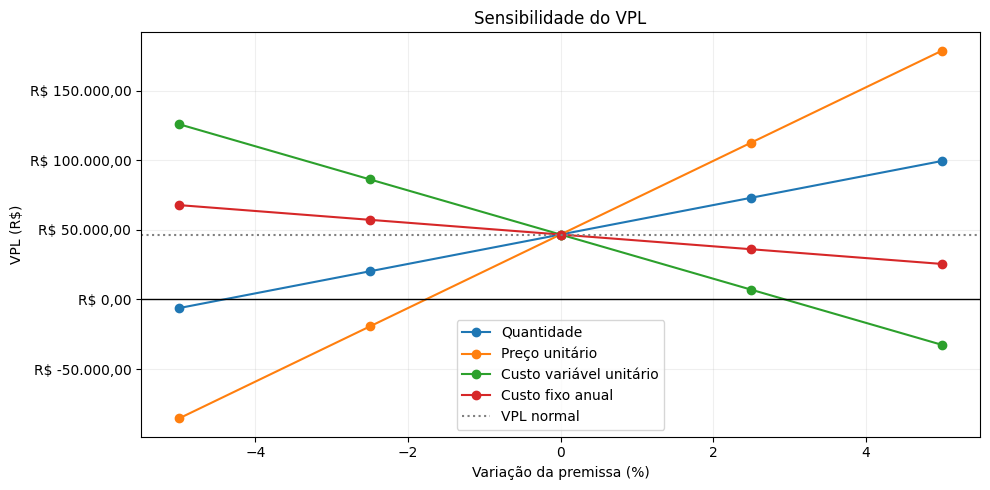

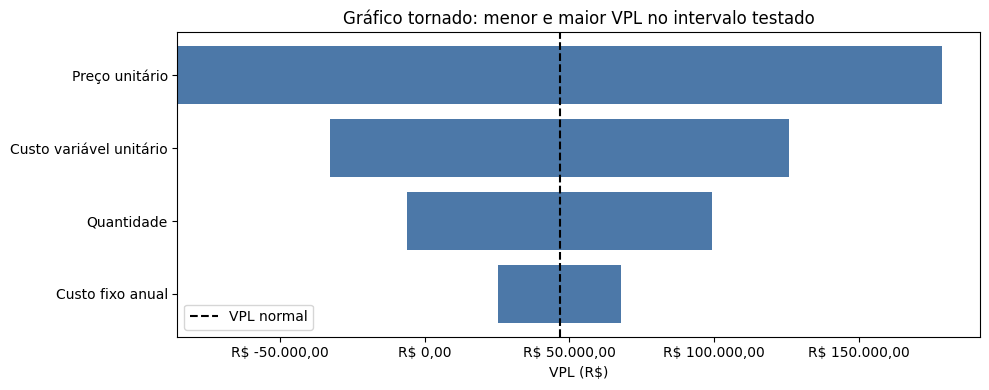

Maior sensibilidade no intervalo testado: Preço unitário


In [3]:
registros = []
for chave, rotulo in ROTULOS.items():
    for variacao in VARIACOES:
        p = {**BASE, chave: BASE[chave] * (1 + variacao)}
        r = analisar(p)
        registros.append({"Variável": rotulo, "Variação": variacao,
                          "Valor da premissa": p[chave], "VPL": r["VPL"], "TIR": r["TIR"]})
sensibilidade = pd.DataFrame(registros)
display(sensibilidade.style.format({"Variação": percentual, "Valor da premissa": "{:,.2f}",
                                    "VPL": moeda, "TIR": percentual}).hide(axis="index"))
fig, ax = plt.subplots(figsize=(10, 5))
for rotulo, grupo in sensibilidade.groupby("Variável", sort=False):
    ax.plot(grupo["Variação"] * 100, grupo["VPL"], marker="o", label=rotulo)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(normal["VPL"], color="gray", linestyle=":", label="VPL normal")
ax.set(xlabel="Variação da premissa (%)", ylabel="VPL (R$)", title="Sensibilidade do VPL")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: moeda(v)))
ax.legend(); ax.grid(alpha=.2); fig.tight_layout(); plt.show()

tornado = sensibilidade.groupby("Variável")["VPL"].agg(["min", "max"])
tornado["Amplitude"] = tornado["max"] - tornado["min"]
tornado = tornado.sort_values("Amplitude")
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(tornado.index, tornado["Amplitude"], left=tornado["min"], color="#4c78a8")
ax.axvline(normal["VPL"], color="black", linestyle="--", label="VPL normal")
ax.set(xlabel="VPL (R$)", title="Gráfico tornado: menor e maior VPL no intervalo testado")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: moeda(v)))
ax.legend(); fig.tight_layout(); plt.show()
print("Maior sensibilidade no intervalo testado:", tornado.index[-1])


## 3. Sensibilidade conjunta: preço × quantidade

Reprodução das duas tabelas da planilha, com custos mantidos no cenário normal. Valores de TIR na tabela são apresentados em percentuais.


VPL


Quantidade anual,475,490,500,515,525
Preço (R$),,,,,
2375,"R$ -131.526,39","R$ -103.812,06","R$ -85.335,83","R$ -57.621,50","R$ -39.145,27"
2400,"R$ -106.451,52","R$ -77.945,35","R$ -58.941,23","R$ -30.435,05","R$ -11.430,94"
2450,"R$ -56.301,77","R$ -26.211,92","R$ -6.152,02","R$ 23.937,83","R$ 43.997,73"
2500,"R$ -6.152,02","R$ 25.521,51","R$ 46.637,19","R$ 78.310,72","R$ 99.426,41"
2550,"R$ 43.997,73","R$ 77.254,94","R$ 99.426,41","R$ 132.683,61","R$ 154.855,08"
2600,"R$ 94.147,49","R$ 128.988,36","R$ 152.215,62","R$ 187.056,50","R$ 210.283,75"
2625,"R$ 119.222,36","R$ 154.855,08","R$ 178.610,22","R$ 214.242,94","R$ 237.998,09"


TIR


Quantidade anual,475,490,500,515,525
Preço (R$),,,,,
2375,"9,10%","10,81%","11,94%","13,61%","14,71%"
2400,"10,65%","12,39%","13,53%","15,22%","16,34%"
2450,"13,69%","15,47%","16,64%","18,38%","19,53%"
2500,"16,64%","18,47%","19,68%","21,46%","22,64%"
2550,"19,53%","21,40%","22,64%","24,48%","25,69%"
2600,"22,35%","24,27%","25,54%","27,43%","28,67%"
2625,"23,74%","25,69%","26,97%","28,89%","30,15%"


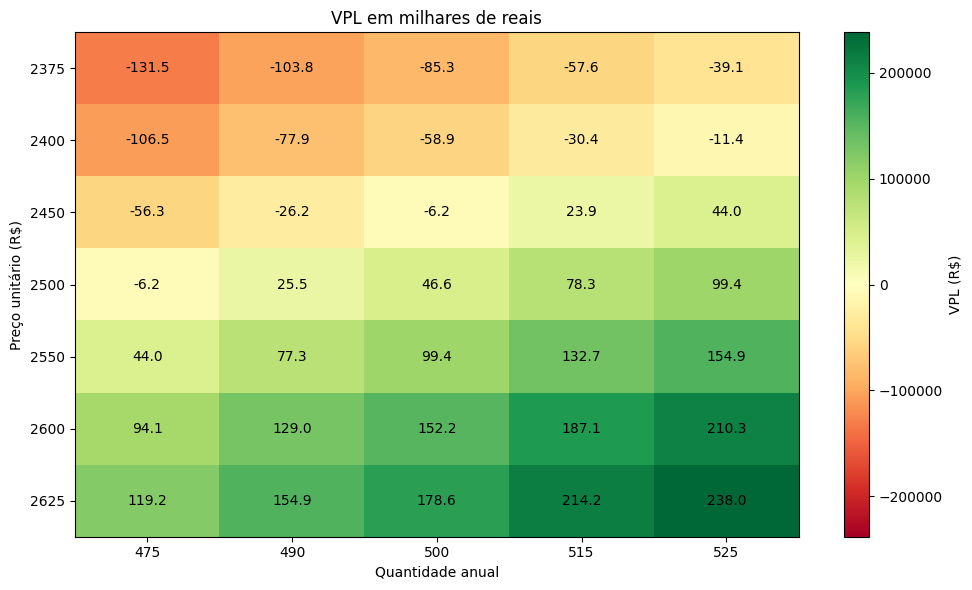

In [4]:
matriz_vpl = pd.DataFrame(index=PRECOS, columns=QUANTIDADES, dtype=float)
matriz_tir = matriz_vpl.copy()
for preco in PRECOS:
    for quantidade in QUANTIDADES:
        r = analisar({**BASE, "preco": preco, "quantidade": quantidade})
        matriz_vpl.loc[preco, quantidade] = r["VPL"]
        matriz_tir.loc[preco, quantidade] = r["TIR"]
for matriz in [matriz_vpl, matriz_tir]:
    matriz.index.name = "Preço (R$)"
    matriz.columns.name = "Quantidade anual"
print("VPL")
display(matriz_vpl.style.format(moeda))
print("TIR")
display(matriz_tir.style.format(percentual))
fig, ax = plt.subplots(figsize=(10, 6))
limite = max(abs(matriz_vpl.to_numpy()).max(), 1)
im = ax.imshow(matriz_vpl, cmap="RdYlGn", vmin=-limite, vmax=limite, aspect="auto")
ax.set_xticks(range(len(QUANTIDADES)), QUANTIDADES)
ax.set_yticks(range(len(PRECOS)), PRECOS)
for i in range(len(PRECOS)):
    for j in range(len(QUANTIDADES)):
        ax.text(j, i, f"{matriz_vpl.iloc[i,j]/1000:.1f}", ha="center", va="center", fontsize=10)
ax.set(xlabel="Quantidade anual", ylabel="Preço unitário (R$)", title="VPL em milhares de reais")
fig.colorbar(im, ax=ax, label="VPL (R$)")
fig.tight_layout(); plt.show()


## 4. Cenários e risco

As quatro premissas operacionais mudam simultaneamente. As probabilidades são 50% para o normal e 25% para cada extremo, como no exercício. O risco é calculado sobre a distribuição dos três VPLs: variância ponderada, desvio padrão e coeficiente de variação (desvio padrão / VPL esperado). Não se usa desvio padrão amostral. A probabilidade de VPL negativo considera somente os cenários e pesos informados.


,Probabilidade,Quantidade,Preço,CV unitário,CF anual,FCO,VPL,TIR
Cenário,,,,,,,,
Normal,"50,00%",500.00,"R$ 2.500,00","R$ 1.500,00","R$ 200.000,00","R$ 249.000,00","R$ 46.637,19","19,68%"
Pessimista,"25,00%",475.00,"R$ 2.375,00","R$ 1.575,00","R$ 210.000,00","R$ 163.200,00","R$ -227.866,71","2,88%"
Otimista,"25,00%",525.00,"R$ 2.625,00","R$ 1.425,00","R$ 190.000,00","R$ 341.400,00","R$ 342.256,78","35,59%"


VPL esperado: R$ 51.916,12
Variância (R$²): 40,657,965,698.07
Desvio padrão: R$ 201.638,20
Coeficiente de variação: 3.8839
Probabilidade de VPL negativo nos cenários: 25,00%


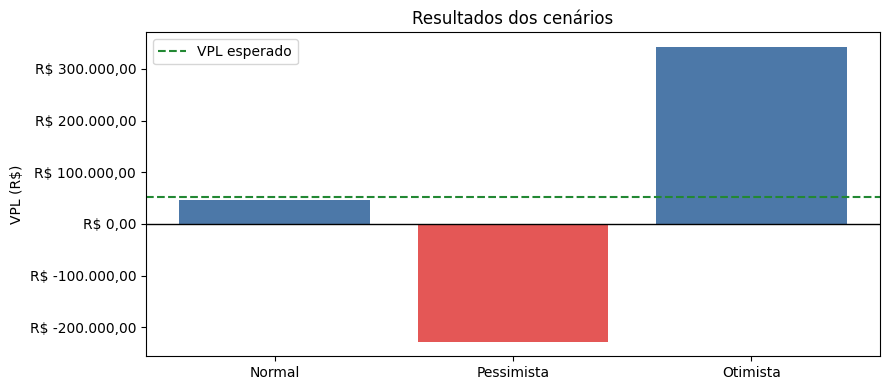

In [5]:
linhas = []
fluxos_cenarios = {}
for nome, cfg in CENARIOS.items():
    v = cfg["variacao"]
    p = dict(BASE)
    for chave in ["quantidade", "preco"]:
        p[chave] *= 1 + v
    for chave in ["custo_variavel", "custo_fixo"]:
        p[chave] *= 1 - v
    r = analisar(p)
    linhas.append({"Cenário": nome, "Probabilidade": cfg["probabilidade"],
        "Quantidade": p["quantidade"], "Preço": p["preco"],
        "CV unitário": p["custo_variavel"], "CF anual": p["custo_fixo"],
        "FCO": r["FCO"], "VPL": r["VPL"], "TIR": r["TIR"]})
    fluxos_cenarios[nome] = r["tabela"]
cenarios = pd.DataFrame(linhas).set_index("Cenário")
probs = cenarios["Probabilidade"].to_numpy()
if np.any(probs < 0) or not np.isclose(probs.sum(), 1):
    raise ValueError("As probabilidades devem ser não negativas e somar 100%.")
vpls = cenarios["VPL"].to_numpy()
esperado = np.dot(probs, vpls)
variancia = np.dot(probs, (vpls - esperado)**2)
desvio = np.sqrt(variancia)
cv = desvio / esperado if not np.isclose(esperado, 0) else np.nan
prob_negativo = probs[vpls < 0].sum()
display(cenarios.style.format({"Probabilidade": percentual, "Quantidade": "{:,.2f}",
    "Preço": moeda, "CV unitário": moeda, "CF anual": moeda, "FCO": moeda, "VPL": moeda, "TIR": percentual}))
print("VPL esperado:", moeda(esperado))
print("Variância (R$²):", f"{variancia:,.2f}")
print("Desvio padrão:", moeda(desvio))
print("Coeficiente de variação:", f"{cv:.4f}" if np.isfinite(cv) else "não definido")
if esperado <= 0:
    print("Com VPL esperado não positivo, o CV não é adequado para comparar risco relativo.")
print("Probabilidade de VPL negativo nos cenários:", percentual(prob_negativo))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cenarios.index, cenarios["VPL"], color=["#4c78a8" if v >= 0 else "#e45756" for v in vpls])
ax.axhline(0, color="black", linewidth=1)
ax.axhline(esperado, color="#228833", linestyle="--", label="VPL esperado")
ax.set(ylabel="VPL (R$)", title="Resultados dos cenários")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: moeda(v)))
ax.legend(); fig.tight_layout(); plt.show()


In [8]:
# Cálculo dos Pontos de Equilíbrio e do Grau de Alavancagem Operacional (GAO)
# Premissas do cenário Base
preco = BASE["preco"]
cv_unitario = BASE["custo_variavel"]
custo_fixo = BASE["custo_fixo"]
investimento = BASE["investimento"]
anos = BASE["anos"]
qtd_base = BASE["quantidade"]

# Depreciação Linear anual
depreciacao = investimento / anos

# Margem de Contribuição Unitária
margem_contribuicao = preco - cv_unitario

# 1. Ponto de Equilíbrio Contábil (PEC)
# PEC = (Custos Fixos + Depreciação) / Margem de Contribuição Unitária
pec = (custo_fixo + depreciacao) / margem_contribuicao

# 2. Ponto de Equilíbrio Financeiro (PEF)
# PEF = Custos Fixos / Margem de Contribuição Unitária
pef = custo_fixo / margem_contribuicao

# 3. Ponto de Equilíbrio de Caixa (PE Caixa)
# PE Caixa = Custos Fixos / Margem de Contribuição Unitária (igual ao financeiro quando não há outros fluxos fixos de caixa não-operacionais)
pe_caixa = custo_fixo / margem_contribuicao

# 4. Grau de Alavancagem Operacional (GAO tradicional, via LAJIR)
margem_total = qtd_base * margem_contribuicao
lajir_sem_ir = margem_total - custo_fixo - depreciacao
gao_lajir = margem_total / lajir_sem_ir if lajir_sem_ir != 0 else np.nan

# 5. Grau de Alavancagem Operacional via FCO (IR = 0 para estes cálculos específicos)
# FCO = LAJIR + Depreciação = Margem_Total - Custos_Fixos
fco_sem_ir = margem_total - custo_fixo
gao_fco = margem_total / fco_sem_ir if fco_sem_ir != 0 else np.nan

# Exibição dos resultados
print("--- ANÁLISE DE PONTOS DE EQUILÍBRIO E ALAVANCAGEM (IR = 0) ---")
print(f"Margem de Contribuição Unitária: {moeda(margem_contribuicao)}")
print(f"Depreciação Anual: {moeda(depreciacao)}")
print(f"Ponto de Equilíbrio Contábil (PEC): {pec:.2f} unidades/ano")
print(f"Ponto de Equilíbrio Financeiro (PEF): {pef:.2f} unidades/ano")
print(f"Ponto de Equilíbrio de Caixa: {pe_caixa:.2f} unidades/ano")
print(f"Grau de Alavancagem Operacional (GAO pelo LAJIR) para Q={qtd_base}: {gao_lajir:.4f}")
print(f"Grau de Alavancagem Operacional (GAO pelo FCO) para Q={qtd_base}: {gao_fco:.4f}")


--- ANÁLISE DE PONTOS DE EQUILÍBRIO E ALAVANCAGEM (IR = 0) ---
Margem de Contribuição Unitária: R$ 1.000,00
Depreciação Anual: R$ 150.000,00
Ponto de Equilíbrio Contábil (PEC): 350.00 unidades/ano
Ponto de Equilíbrio Financeiro (PEF): 200.00 unidades/ano
Ponto de Equilíbrio de Caixa: 200.00 unidades/ano
Grau de Alavancagem Operacional (GAO pelo LAJIR) para Q=500: 3.3333
Grau de Alavancagem Operacional (GAO pelo FCO) para Q=500: 1.6667


## 5. Exportar os resultados

Esta célula gera um Excel com as premissas e resultados recalculados pelo Python. As tabelas exportadas contêm valores, sem fórmulas. No Colab, clique no botão abaixo para baixar o arquivo.


In [9]:
arquivo = "resultados_sensibilidade_cenarios.xlsx"
resumo_risco = pd.DataFrame({"Medida": ["VPL esperado (R$)", "Variância (R$²)",
    "Desvio padrão (R$)", "Coeficiente de variação", "Probabilidade de VPL negativo"],
    "Valor": [esperado, variancia, desvio, cv, prob_negativo]})

# DataFrame com os resultados de Pontos de Equilíbrio e GAO
resumo_equilibrio_gao = pd.DataFrame({
    "Métrica": [
        "Margem de Contribuição Unitária (R$)",
        "Depreciação Anual (R$)",
        "Ponto de Equilíbrio Contábil (PEC - unid/ano)",
        "Ponto de Equilíbrio Financeiro (PEF - unid/ano)",
        "Ponto de Equilíbrio de Caixa (PE Caixa - unid/ano)",
        f"Grau de Alavancagem Operacional (GAO pelo LAJIR) para Q={qtd_base}",
        f"Grau de Alavancagem Operacional (GAO pelo FCO) para Q={qtd_base}"
    ],
    "Valor": [
        margem_contribuicao,
        depreciacao,
        pec,
        pef,
        pe_caixa,
        gao_lajir,
        gao_fco
    ]
})

with pd.ExcelWriter(arquivo, engine="openpyxl") as writer:
    pd.DataFrame(BASE.items(), columns=["Premissa", "Valor"]).to_excel(writer, sheet_name="Premissas", index=False)
    pd.DataFrame({"Premissa": ["Benefício fiscal imediato"], "Valor": [BENEFICIO_FISCAL_IMEDIATO]}).to_excel(
        writer, sheet_name="Premissas", index=False, startrow=len(BASE)+3)
    normal["tabela"].to_excel(writer, sheet_name="Fluxo normal")
    sensibilidade.to_excel(writer, sheet_name="Sensibilidade", index=False)
    matriz_vpl.to_excel(writer, sheet_name="Matriz VPL")
    matriz_tir.to_excel(writer, sheet_name="Matriz TIR")
    cenarios.to_excel(writer, sheet_name="Cenarios")
    resumo_risco.to_excel(writer, sheet_name="Risco", index=False)
    resumo_equilibrio_gao.to_excel(writer, sheet_name="Equilibrio_Alavancagem", index=False)
    for nome, tabela in fluxos_cenarios.items():
        tabela.to_excel(writer, sheet_name="Fluxo " + nome)

print("Arquivo gerado:", arquivo)
try:
    from google.colab import files
    import ipywidgets as widgets
    botao = widgets.Button(description="Baixar resultados", button_style="success")
    botao.on_click(lambda _: files.download(arquivo))
    display(botao)
except ImportError:
    print("Fora do Colab, o arquivo foi salvo no diretório de execução.")

Arquivo gerado: resultados_sensibilidade_cenarios.xlsx


Button(button_style='success', description='Baixar resultados', style=ButtonStyle())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>